# 04 — GLM and FIR Analysis

This notebook walks through two standard fMRI analysis tools using **nilearn**:

| Method | Question |
|--------|----------|
| **GLM** (canonical HRF) | Is there a significant *average* response to an event? |
| **FIR** (Finite Impulse Response) | What does the response *look like* over time around an event? |

Everything runs on **synthetic data** — no files needed.

**Dependencies:** `nilearn`, `numpy`, `matplotlib`, `pandas`

## 1 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nilearn.glm.first_level import make_first_level_design_matrix, run_glm

rng = np.random.default_rng(42)

# ── Scan parameters ────────────────────────────────────────────────────
TR          = 2.0       # repetition time (seconds)
N_SCANS     = 300       # number of volumes
N_ROIS      = 5         # number of brain regions

# ── Event onsets (seconds) ─────────────────────────────────────────────
event_onsets = np.array([20, 45, 80, 110, 150, 175, 210, 235, 270,
                          310, 345, 380, 420, 450, 480], dtype=float)

# ── Frame times: one entry per volume ──────────────────────────────────
frame_times = np.arange(N_SCANS) * TR

# ── Helper: reassemble betas from run_glm output ───────────────────────
# run_glm groups voxels by AR model label; each group's theta only covers
# its own voxels. This collects them into one (n_params × n_voxels) array.
def get_betas(labels, results, n_params):
    betas = np.zeros((n_params, len(labels)))
    for label, result in results.items():
        betas[:, labels == label] = result.theta
    return betas

print(f'Total scan time : {frame_times[-1]:.0f} s')
print(f'Events at (s)   : {event_onsets}')

Total scan time : 598 s
Events at (s)   : [ 20.  45.  80. 110. 150. 175. 210. 235. 270. 310. 345. 380. 420. 450.
 480.]


## 2 — Simulate BOLD Timeseries

We convolve a boxcar event train with an HRF and add noise,
so the ground-truth signal is known.

BOLD shape: (300, 5)  (timepoints × ROIs)


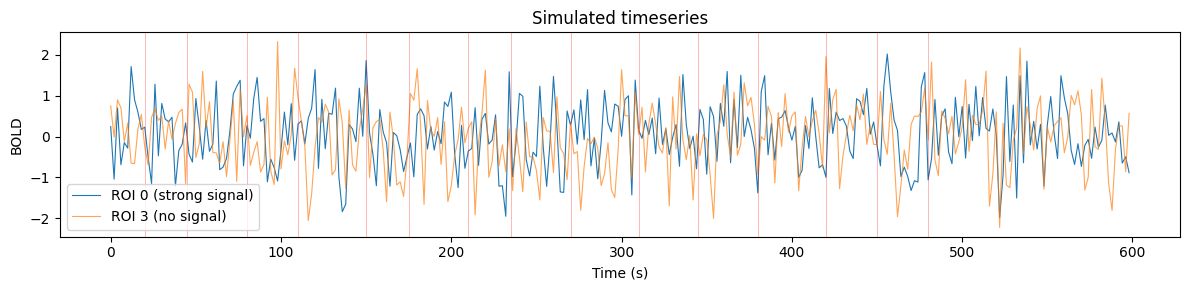

In [2]:
from nilearn.glm.first_level import spm_hrf

# Build a simple HRF at the TR resolution
hrf = spm_hrf(TR, oversampling=1)

# Build neural signal: 1 at each event onset TR, 0 elsewhere
neural = np.zeros(N_SCANS)
onset_trs = (event_onsets / TR).astype(int)
neural[onset_trs] = 1.0

# Convolve with HRF
bold_clean = np.convolve(neural, hrf)[:N_SCANS]

# Replicate across ROIs with varying signal strength + noise
signal_strength = np.array([1.5, 1.0, 0.5, 0.0, -0.8])   # roi-specific
bold = (bold_clean[:, None] * signal_strength) + rng.normal(0, 0.8, (N_SCANS, N_ROIS))

print(f'BOLD shape: {bold.shape}  (timepoints × ROIs)')

plt.figure(figsize=(12, 3))
plt.plot(frame_times, bold[:, 0], lw=0.8, label='ROI 0 (strong signal)')
plt.plot(frame_times, bold[:, 3], lw=0.8, label='ROI 3 (no signal)', alpha=0.7)
for t in event_onsets:
    plt.axvline(t, color='r', lw=0.5, alpha=0.4)
plt.xlabel('Time (s)'); plt.ylabel('BOLD'); plt.title('Simulated timeseries')
plt.legend(); plt.tight_layout(); plt.show()

---
## 3 — GLM with Canonical HRF

**How it works:**
1. Build an *events* DataFrame (trial_type, onset, duration)
2. `make_first_level_design_matrix` convolves events with the SPM HRF → one regressor
3. `run_glm` fits OLS at each ROI
4. Extract the beta (effect size) for the event regressor

Design matrix columns: ['event', 'drift_1', 'drift_2', 'drift_3', 'constant']
Design matrix shape  : (300, 5)


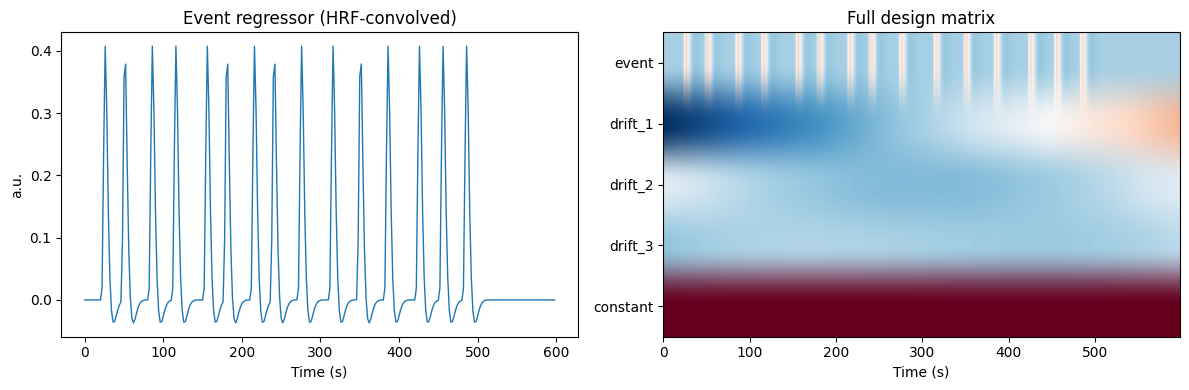

In [3]:
# ── 3a. Build events DataFrame ─────────────────────────────────────────
events = pd.DataFrame({
    'trial_type': 'event',
    'onset':      event_onsets,
    'duration':   TR             # instantaneous (1 TR)
})

# ── 3b. Design matrix ──────────────────────────────────────────────────
glm_dm = make_first_level_design_matrix(
    frame_times,
    events,
    hrf_model='spm',
    drift_model='polynomial',
    drift_order=3,
)

print('Design matrix columns:', list(glm_dm.columns))
print('Design matrix shape  :', glm_dm.shape)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(frame_times, glm_dm['event'], lw=1)
axes[0].set(title='Event regressor (HRF-convolved)', xlabel='Time (s)', ylabel='a.u.')
axes[1].imshow(glm_dm.values.T, aspect='auto', cmap='RdBu_r',
               extent=[frame_times[0], frame_times[-1], len(glm_dm.columns)-0.5, -0.5])
axes[1].set_yticks(range(len(glm_dm.columns))); axes[1].set_yticklabels(glm_dm.columns)
axes[1].set(title='Full design matrix', xlabel='Time (s)')
plt.tight_layout(); plt.show()

GLM betas per ROI: [ 1.121  0.628  0.417 -0.417 -1.069]
Ground-truth signal strengths: [ 1.5  1.   0.5  0.  -0.8]


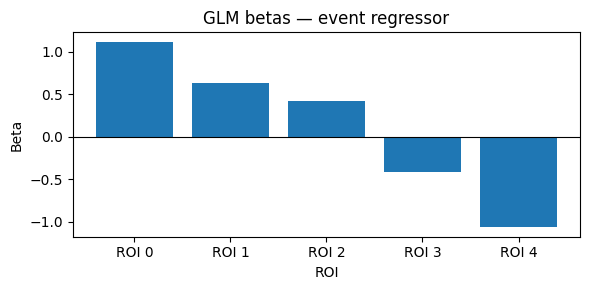

In [4]:
# ── 3c. Fit GLM ────────────────────────────────────────────────────────
labels, results = run_glm(bold, glm_dm.values)

# ── 3d. Extract betas for the event regressor ──────────────────────────
theta      = get_betas(labels, results, len(glm_dm.columns))  # (n_params, N_ROIS)
event_idx  = list(glm_dm.columns).index('event')
glm_betas  = theta[event_idx, :]   # one beta per ROI

print('GLM betas per ROI:', np.round(glm_betas, 3))
print('Ground-truth signal strengths:', signal_strength)

plt.figure(figsize=(6, 3))
plt.bar(range(N_ROIS), glm_betas)
plt.axhline(0, color='k', lw=0.8)
plt.xlabel('ROI'); plt.ylabel('Beta'); plt.title('GLM betas — event regressor')
plt.xticks(range(N_ROIS), [f'ROI {i}' for i in range(N_ROIS)])
plt.tight_layout(); plt.show()

### 3e. Two-condition GLM (e.g. condition A vs B)

Just add more rows to the events DataFrame with different `trial_type` labels.

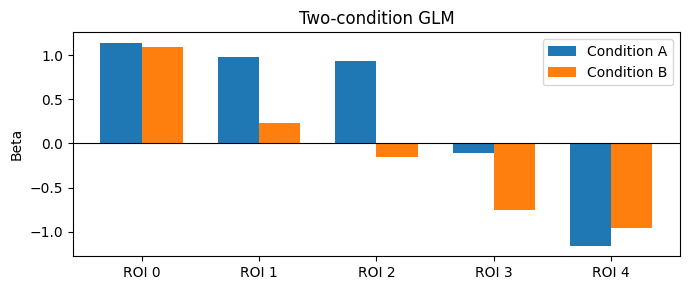

In [5]:
onsets_A = event_onsets[:8]    # first 8 events → condition A
onsets_B = event_onsets[8:]    # last 7 events  → condition B

events_AB = pd.concat([
    pd.DataFrame({'trial_type': 'A', 'onset': onsets_A, 'duration': TR}),
    pd.DataFrame({'trial_type': 'B', 'onset': onsets_B, 'duration': TR}),
], ignore_index=True)

glm_dm_AB = make_first_level_design_matrix(
    frame_times, events_AB,
    hrf_model='spm', drift_model='polynomial', drift_order=3,
)

labels_AB, results_AB = run_glm(bold, glm_dm_AB.values)
theta_AB = get_betas(labels_AB, results_AB, len(glm_dm_AB.columns))
beta_A = theta_AB[list(glm_dm_AB.columns).index('A'), :]
beta_B = theta_AB[list(glm_dm_AB.columns).index('B'), :]

x = np.arange(N_ROIS); w = 0.35
plt.figure(figsize=(7, 3))
plt.bar(x - w/2, beta_A, w, label='Condition A')
plt.bar(x + w/2, beta_B, w, label='Condition B')
plt.axhline(0, color='k', lw=0.8)
plt.xticks(x, [f'ROI {i}' for i in range(N_ROIS)])
plt.ylabel('Beta'); plt.title('Two-condition GLM'); plt.legend()
plt.tight_layout(); plt.show()

---
## 4 — FIR (Finite Impulse Response)

**How it works:**
Instead of one HRF-convolved regressor, FIR creates a **separate regressor for each time lag** around the event.
The betas across lags give you the full peri-event response shape — no HRF assumption needed.

**Key detail — centering the window:**  
nilearn's FIR only looks *forward* in time (`fir_delays` = 0, 1, 2 …).  
To capture ±N TRs around an event, shift onsets *backward* by half the window:
```
onset_adjusted = event_onset - (window_size // 2) * TR
```

In [6]:
# ── 4a. FIR parameters ─────────────────────────────────────────────────
FIR_WINDOW  = 21        # total time-points: captures ±10 TRs
fir_delays  = range(FIR_WINDOW)
time_axis   = (np.arange(FIR_WINDOW) - FIR_WINDOW // 2) * TR   # in seconds

# ── 4b. Shift onsets so window is centred on events ────────────────────
onsets_shifted = event_onsets - (FIR_WINDOW // 2) * TR

events_fir = pd.DataFrame({
    'trial_type': 'event',
    'onset':      onsets_shifted,
    'duration':   TR
})

# ── 4c. Design matrix with FIR HRF model ──────────────────────────────
fir_dm = make_first_level_design_matrix(
    frame_times,
    events_fir,
    hrf_model='fir',
    fir_delays=fir_delays,
    drift_model='polynomial',
    drift_order=3,
)

print(f'FIR design matrix: {fir_dm.shape}  ({FIR_WINDOW} FIR regressors + drift)')

# ── 4d. Fit and extract betas ──────────────────────────────────────────
fir_labels, fir_results = run_glm(bold, fir_dm.values)
fir_theta = get_betas(fir_labels, fir_results, len(fir_dm.columns))

# First FIR_WINDOW rows are the FIR betas (one per lag)
fir_betas = fir_theta[:FIR_WINDOW, :]   # (FIR_WINDOW, N_ROIS)
print(f'FIR betas shape: {fir_betas.shape}  (lags × ROIs)')

FIR design matrix: (300, 25)  (21 FIR regressors + drift)
FIR betas shape: (21, 5)  (lags × ROIs)


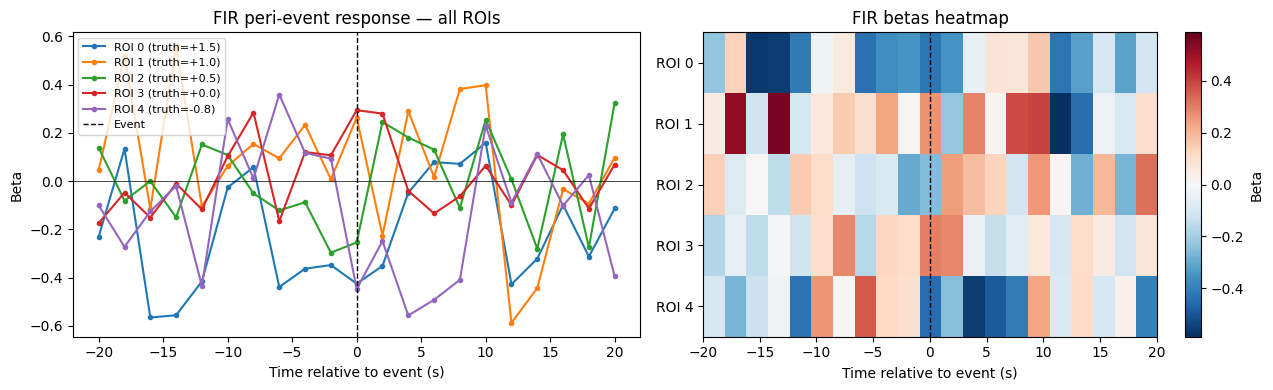

In [7]:
# ── 4e. Plot peri-event response (FIR time course) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: all ROIs
for roi in range(N_ROIS):
    axes[0].plot(time_axis, fir_betas[:, roi], marker='o', ms=3,
                 label=f'ROI {roi} (truth={signal_strength[roi]:+.1f})')
axes[0].axvline(0, color='k', lw=1, ls='--', label='Event')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set(xlabel='Time relative to event (s)', ylabel='Beta',
            title='FIR peri-event response — all ROIs')
axes[0].legend(fontsize=8)

# Right: heatmap (ROIs × lags)
lim = np.abs(fir_betas).max()
im = axes[1].imshow(fir_betas.T, aspect='auto', cmap='RdBu_r',
                    vmin=-lim, vmax=lim,
                    extent=[time_axis[0], time_axis[-1], N_ROIS - 0.5, -0.5])
axes[1].axvline(0, color='k', lw=1, ls='--')
axes[1].set_yticks(range(N_ROIS)); axes[1].set_yticklabels([f'ROI {i}' for i in range(N_ROIS)])
axes[1].set(xlabel='Time relative to event (s)', title='FIR betas heatmap')
plt.colorbar(im, ax=axes[1], label='Beta')

plt.tight_layout(); plt.show()

### 4f. Two-condition FIR (compare response shapes)

Same trick as the two-condition GLM — just split events into conditions.

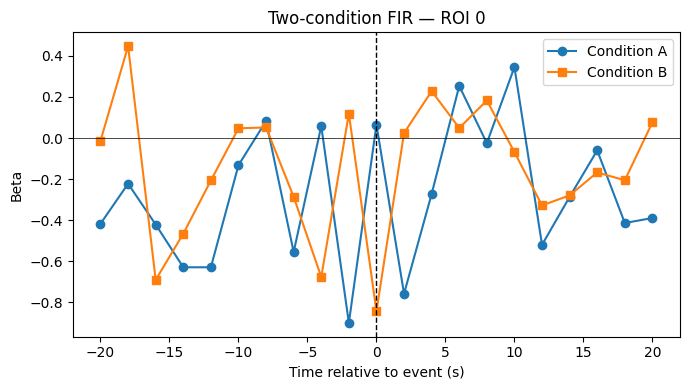

In [8]:
events_fir_AB = pd.concat([
    pd.DataFrame({'trial_type': 'A', 'onset': onsets_A - (FIR_WINDOW // 2) * TR, 'duration': TR}),
    pd.DataFrame({'trial_type': 'B', 'onset': onsets_B - (FIR_WINDOW // 2) * TR, 'duration': TR}),
], ignore_index=True)

fir_dm_AB = make_first_level_design_matrix(
    frame_times, events_fir_AB,
    hrf_model='fir', fir_delays=fir_delays,
    drift_model='polynomial', drift_order=3,
)

fir_labels_AB, fir_results_AB = run_glm(bold, fir_dm_AB.values)
theta_AB_fir = get_betas(fir_labels_AB, fir_results_AB, len(fir_dm_AB.columns))

# Columns are ordered: A_delay_0..A_delay_N, B_delay_0..B_delay_N, drift
betas_A = theta_AB_fir[:FIR_WINDOW, 0]              # ROI 0, condition A
betas_B = theta_AB_fir[FIR_WINDOW:2*FIR_WINDOW, 0]  # ROI 0, condition B

plt.figure(figsize=(7, 4))
plt.plot(time_axis, betas_A, 'o-', label='Condition A')
plt.plot(time_axis, betas_B, 's-', label='Condition B')
plt.axvline(0, color='k', lw=1, ls='--'); plt.axhline(0, color='k', lw=0.5)
plt.xlabel('Time relative to event (s)'); plt.ylabel('Beta')
plt.title('Two-condition FIR — ROI 0'); plt.legend()
plt.tight_layout(); plt.show()

---
## Summary

```
GLM (canonical HRF)
  events df  →  make_first_level_design_matrix(..., hrf_model='spm')  →  run_glm
  → one beta per ROI per condition

FIR
  shift onsets by -(window//2)*TR
  events df  →  make_first_level_design_matrix(..., hrf_model='fir', fir_delays=range(N))
  → run_glm  →  theta[:N, :]  = betas for each lag (peri-event time course)
```

**When to use which:**
- GLM → simple test: *is there an effect?* (one number per condition)
- FIR → shape characterisation: *when does the effect peak, how long does it last?* (no HRF assumption)

---
## 5 — Whole-Brain GLM → Beta NIfTI

Same GLM as above, but run on every voxel in the brain and saved back as a NIfTI volume.

The only new steps are:
1. Flatten 4D → 2D, run GLM, reshape the betas back to 3D
2. Apply a brain mask so we skip background voxels
3. Save with `nibabel`

The resulting beta map can be visualised directly with **notebook 03** (`03_nifti_surface_projection.ipynb`).

In [ ]:
import nibabel as nib
from nilearn import image, datasets

# ── 5a. Configuration ──────────────────────────────────────────────────
NIFTI_PATH  = '/path/to/your/preprocessed_bold.nii.gz'   # <-- change this
OUTPUT_PATH = 'beta_map_event.nii.gz'
N_ROIS_WB   = 100   # Schaefer parcels — used only to define the brain mask

# ── 5b. Load data ──────────────────────────────────────────────────────
img     = nib.load(NIFTI_PATH)
data_4d = img.get_fdata()                     # (X, Y, Z, T)
X, Y, Z, T = data_4d.shape

# ── 5c. Brain mask from Schaefer atlas ────────────────────────────────
# Works regardless of whether the data is z-scored or not.
schaefer    = datasets.fetch_atlas_schaefer_2018(n_rois=N_ROIS_WB, resolution_mm=2)
atlas_img   = image.resample_to_img(schaefer['maps'], img, interpolation='nearest')
atlas_data  = atlas_img.get_fdata()

mask  = atlas_data != 0                       # (X, Y, Z) bool
n_vox = mask.sum()

# Flatten to (T, n_voxels) — only in-mask voxels
bold_2d = data_4d[mask, :].T                  # (T, n_vox)
frame_times_wb = np.arange(T) * TR

print(f'Data shape    : {data_4d.shape}')
print(f'In-mask voxels: {n_vox} / {X*Y*Z}')

In [ ]:
# ── 5c. Build design matrix & fit ─────────────────────────────────────
# Reuse the same events DataFrame from section 3
dm_wb = make_first_level_design_matrix(
    frame_times_wb, events,
    hrf_model='spm', drift_model='polynomial', drift_order=3,
)

wb_labels, wb_results = run_glm(bold_2d, dm_wb.values)
theta_wb = get_betas(wb_labels, wb_results, len(dm_wb.columns))  # (n_params, n_vox)

# ── 5d. Extract event beta and reshape to 3D volume ───────────────────
event_idx    = list(dm_wb.columns).index('event')
beta_1d      = theta_wb[event_idx, :]         # (n_vox,)

beta_vol     = np.zeros((X, Y, Z))
beta_vol[mask] = beta_1d                      # place betas back into brain

# ── 5e. Save as NIfTI ─────────────────────────────────────────────────
beta_img = nib.Nifti1Image(beta_vol, affine=img.affine, header=img.header)
nib.save(beta_img, OUTPUT_PATH)

print(f'Beta map saved to: {OUTPUT_PATH}')
print(f'Non-zero voxels  : {(beta_vol != 0).sum()}')
print(f'Value range      : [{beta_vol[mask].min():.3f}, {beta_vol[mask].max():.3f}]')
print()
print('Tip: open the saved NIfTI in notebook 03 (03_nifti_surface_projection.ipynb)')
print('     to project the beta map onto the brain surface.')